# StatArb residual reversion — research notebook

A market-neutral statistical-arbitrage strategy (Avellaneda–Lee residual reversion) taken through a
full research workflow: reproduce, **attack** (survivorship audits), quantify which production layers
matter (ablation), and ask whether a meta-model can predict *which* signals revert.

**This notebook never re-runs the backtest.** It reads the artifacts the audited engine wrote
(`artifacts/statarb/…`) — the compute/present seam that keeps the headline number honest.

*Paper trading only. Nothing here places real orders.*

In [1]:
from pathlib import Path
import warnings; warnings.simplefilter("ignore")
import numpy as np
import pandas as pd
from IPython.display import Image, display

from core.eval.metrics import sharpe, max_drawdown
from tracks.statarb.ml.dataset import build_features, load_log
from tracks.statarb.ml.train import oof_auc_table
from tracks.statarb.ml import evaluate as ev

ROOT = Path.cwd() if (Path.cwd() / "artifacts").exists() else Path.cwd().parents[0]
ABL = ROOT / "artifacts/statarb/ablation"
CONFIG = "costs"   # the equal-weight S&P 500 book whose net Sharpe IS the audited 2.67

## The headline result — does signal *quality* prediction improve the book?

The single most important question in this notebook, up front: if instead of trading **every**
residual signal we trade only those a meta-model rates likely to revert, does the book improve —
**out of sample**? The threshold is pre-registered on earlier trades and reported on held-out later
trades. Reported whichever way it comes out: a null result is itself a finding.

In [2]:
res = ev.evaluate(CONFIG)
gated_table = ev.as_table(res)
print(f"Ungated full-period Sharpe {res['ungated_full_sharpe']} (audited-path anchor, about 2.67). "
      f"Pre-registered threshold {res['threshold']}: kept {res['n_kept']} of "
      f"{res['n_holdout_trades']} held-out trades.")
gated_table

Ungated full-period Sharpe 2.67 (audited-path anchor, about 2.67). Pre-registered threshold 0.7497: kept 1959 of 12295 held-out trades.


,arm,n_trades,win%,mean_pnl,per_trade_sharpe,daily_sharpe,max_dd
0,ungated,12295,70.2,0.0131,0.25,2.65,-0.025
1,gated,1959,76.3,0.0277,0.45,4.08,-0.034


`daily_sharpe` here is a REAL daily Sharpe from the audited engine: sub-threshold signals are zeroed
out of the positions matrix and run through the exact `equal_weight_net` path that produces the 2.67.
The ungated held-out Sharpe (about 2.65) anchors it to the headline. Caveat: this is one
pre-registered held-out split, not cross-validated, so read the lift as directional. Per-trade win
rate and mean P&L are the complementary trade-level view.

## Which production layers actually matter — the ablation

In [3]:
def ablation_table():
    rows = []
    for p in sorted(ABL.glob("*_net.parquet")):
        net = pd.read_parquet(p)["net"].dropna()
        rows.append({"config": p.stem.replace("_net", ""), "n_days": len(net),
                     "sharpe": round(sharpe(net, 252), 2), "max_dd": round(max_drawdown(net), 3)})
    return pd.DataFrame(rows)

ablation_table()

,config,n_days,sharpe,max_dd
0,all_on,2017,2.43,-0.065
1,baseline,2015,3.80,-0.057
2,costs,2015,2.67,-0.063
3,liquidity,2015,2.65,-0.063
4,sector_cap,2017,2.44,-0.065


## Robustness across regimes

A layer's verdict must survive different environments, not one lucky window. Sharpe by calendar year.

In [4]:
net = pd.read_parquet(ABL / f"{CONFIG}_net.parquet")["net"].dropna()
by_year = net.groupby(net.index.year).apply(lambda s: sharpe(s, 252)).round(2)
by_year.rename("sharpe").to_frame()

,sharpe
Date,
2018,3.72
2019,4.70
2020,2.73
2021,3.07
2022,2.88
2023,1.24
2024,3.67
2025,2.05
2026,3.47


## QuantStats tearsheet

The field-standard performance report — cumulative returns, drawdown, rolling Sharpe, monthly heatmap.
Generated to `reports/` and linked here (kept out-of-line so the notebook stays light).

In [5]:
import quantstats as qs
try:
    m = qs.reports.metrics(net, mode="basic", display=False)
    display(m)
except Exception as e:
    print(f"metrics table skipped ({type(e).__name__})")
print(f"Full tearsheet: reports/statarb_tearsheet_{CONFIG}.html")

,Strategy
Start Period,2018-06-27
End Period,2026-07-06
Risk-Free Rate,0
Time in Market,1.0
Cumulative Return,1.69
CAGR﹪,0.13
Sharpe,2.67
Prob. Sharpe Ratio,1.0
Sortino,4.46
Sortino/√2,3.15


Full tearsheet: reports/statarb_tearsheet_costs.html


**Honest note.** QuantStats' Sharpe assumes a risk-free rate and its own periodization; the house
scorecard uses rf=0, ddof=1. The two won't exactly match — a convention difference, not a bug. The
custom deflated-Sharpe (Bailey–López de Prado) remains the multiple-testing guard QuantStats omits.

## The meta-model — walk-forward, leakage-safe

Features are **entry-time only** (an exit-time feature like `holding_days` would leak the label).
Expanding-window monthly training; out-of-fold AUC below.

In [6]:
X, y, dates = build_features(load_log(CONFIG))
print(f"{len(X)} signals · {y.mean():.1%} reverted · {X.shape[1]} entry-time features")
oof_auc_table(X, y, dates)

31008 signals · 71.4% reverted · 16 entry-time features


,model,oof_auc,scored
0,logistic,0.5423,30762
1,random_forest,0.5411,30762
2,xgboost,0.5379,30762


### SHAP — what drives the meta-model

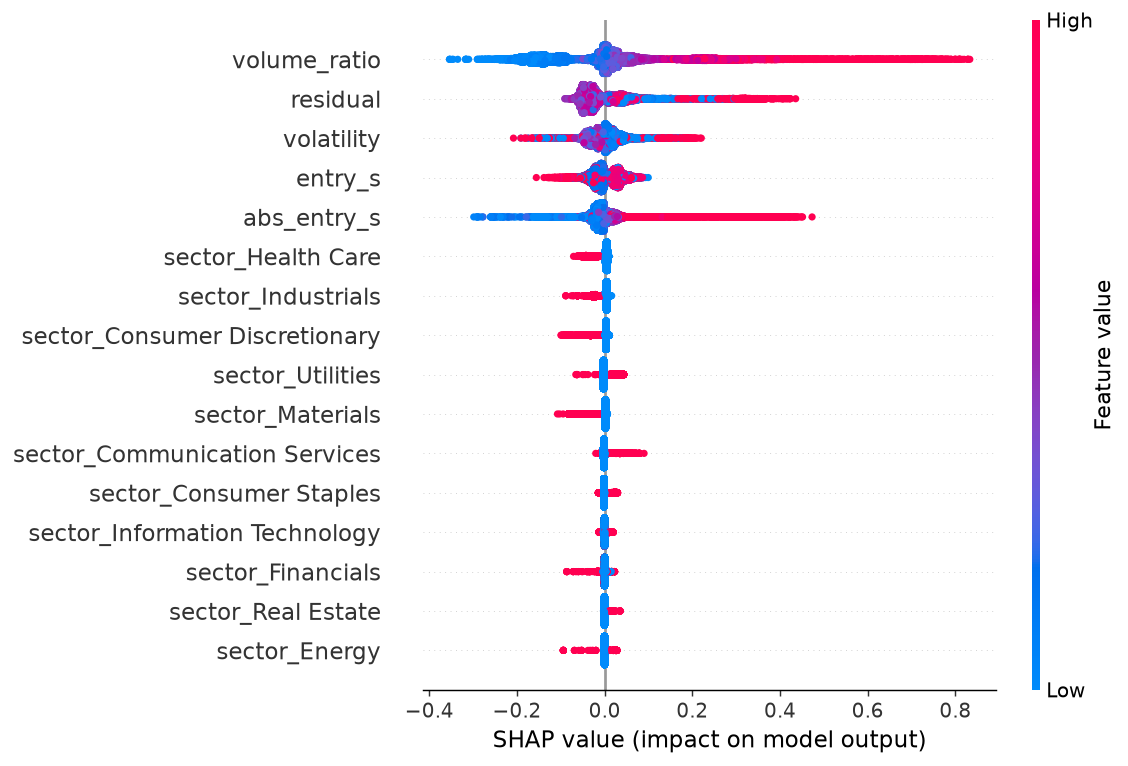

In [7]:
png = ROOT / "reports" / f"shap_beeswarm_{CONFIG}.png"
display(Image(filename=str(png))) if png.exists() else print("run tracks.statarb.ml.explain first")

## Limitations (stated, not buried)

- **Survivorship.** The backward log is survivor-biased on deep-dip longs; the meta-model here is a
  *prototype*. Its clean training set is the forward paper book (survivorship-immune by construction).
- **Reconstruction.** The gated-vs-ungated `daily_sharpe` is from a sparse trade→daily reconstruction;
  per-trade win rate / mean P&L are the trustworthy comparison.
- **Costs & capacity.** Residual reversion is turnover-heavy and cost-sensitive; the ablation charges
  costs explicitly, but real fills, borrow, and impact are not modeled here.

## Conclusion

The strategy is real and its limits are named. The differentiator isn't the Sharpe — it's the
discipline: survivorship audits, an ablation that says which layers earn their keep, and a
leakage-safe meta-model reported whichever way it comes out.